WHT coordinate distribution analysis
Goal: measure the empirical distribution of normalized post-WHT coordinates in SIFT1M (and optionally other datasets) and compare it against the N(0,1) assumption used by computeLloydMax.

Pipeline per vector (mirrors TurboQuantSpace::encodeVector):

L2-normalise → unit vector
Multiply elementwise by rotation_signs (splitmix64, seed=42)
Walsh-Hadamard Transform + 1/√d normalisation
Divide by per-vector σ = std of the rotated coordinates
The resulting values go directly into quantize() and should ideally follow N(0,1).

1. Reproduce the TQ WHT pipeline in Python
We re-implement generateSigns (splitmix64) and randomizedHadamard exactly as in turbo_quant.h.

2. Sanity-check: synthetic Gaussian vectors → should be exactly N(0,1)
3. Load SIFT1M and collect post-WHT coordinates
4. Distribution diagnostics
5. Visual comparison: histogram + Q-Q plot
6. Quantisation error analysis: current Lloyd-Max vs empirical optimal
We measure MSE of the current Gaussian-optimal codebook on the SIFT empirical distribution, then compute what MSE a codebook trained on SIFT samples would achieve.

7. Codebook comparison: where do centroids differ?
Visualise how the Gaussian-trained and SIFT-empirical codebooks diverge for bits=3 (TQ default bits_per_coord=4 → 3 MSE bits).

8. (Optional) Extend to other datasets
If you have HF embeddings cached, compare their distributions against SIFT1M.



In [1]:
import argparse
import csv
import os
import subprocess
import sys
import tarfile
import time
import urllib.request
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm



SIFT_URL = "ftp://ftp.irisa.fr/local/texmex/corpus/sift.tar.gz"
CACHE_DIR = Path.home() / ".cache" / "turboquant" / "sift"


def _read_fvecs(path: Path) -> np.ndarray:
    raw = np.fromfile(path, dtype=np.int32)
    d = int(raw[0])
    n = raw.size // (d + 1)
    view = raw.reshape(n, d + 1)
    return view[:, 1:].copy().view(np.float32)


def _read_ivecs(path: Path) -> np.ndarray:
    raw = np.fromfile(path, dtype=np.int32)
    d = int(raw[0])
    n = raw.size // (d + 1)
    return raw.reshape(n, d + 1)[:, 1:].copy()

def load_sift1m(metric: str = "l2") -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (base[1e6,128], query[1e4,128], gt[1e4,100])."""
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    base_path = CACHE_DIR / "sift_base.fvecs"
    query_path = CACHE_DIR / "sift_query.fvecs"
    gt_path = CACHE_DIR / "sift_groundtruth.ivecs"

    if not (base_path.exists() and query_path.exists() and gt_path.exists()):
        tar_path = CACHE_DIR / "sift.tar.gz"
        if not tar_path.exists():
            subprocess.run(["wget", "-O", str(tar_path), SIFT_URL], check=True)
        print(f"[sift] extracting to {CACHE_DIR}")
        with tarfile.open(tar_path, "r:gz") as tf:
            for member in tf.getmembers():
                name = os.path.basename(member.name)
                if name in ("sift_base.fvecs", "sift_query.fvecs", "sift_groundtruth.ivecs"):
                    member.name = name
                    tf.extract(member, CACHE_DIR, filter='data')
    else:
        print(f"[sift] cached at {CACHE_DIR}")

    print("[sift] reading vectors")
    base = _read_fvecs(base_path)
    query = _read_fvecs(query_path)
    gt = _read_ivecs(gt_path)

    if metric == "cosine":
        base = _l2_normalize(base)
        query = _l2_normalize(query)
        # cached gt was built for raw L2 on un-normalized vectors; rebuild for cosine.
        gt = _compute_gt_l2(base, query, gt_k=gt.shape[1])

    print(f"[sift] base={base.shape} query={query.shape} gt={gt.shape} metric={metric}")
    return base, query, gt

base, query, gt = load_sift1m(metric="l2")


[sift] extracting to /root/.cache/turboquant/sift
[sift] reading vectors
[sift] base=(1000000, 128) query=(10000, 128) gt=(10000, 100) metric=l2


In [2]:
!pip install turboquant-space

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.5/246.5 kB 8.3 MB/s eta 0:00:00


In [4]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# Make sure turboquant is importable (installed via `uv pip install -e .`)
try:
    import turboquant as tq
    print(f"turboquant loaded, TurboQuantSpace dim test: {tq.TurboQuantSpace(128).dim()}")
except ImportError as e:
    print(f"[!] turboquant not found: {e}")
    print("    Run: uv pip install -e . --reinstall  from the repo root")

turboquant loaded, TurboQuantSpace dim test: 128


In [5]:
def splitmix64_signs(d: int, seed: int = 42) -> np.ndarray:
    """Reproduce generateSigns() from turbo_quant.h (splitmix64)."""
    MASK64 = np.uint64(0xFFFFFFFFFFFFFFFF)
    state = np.uint64(seed)
    signs = np.empty(d, dtype=np.float32)
    inc = np.uint64(0x9e3779b97f4a7c15)
    m1  = np.uint64(0xbf58476d1ce4e5b9)
    m2  = np.uint64(0x94d049bb133111eb)
    for i in range(d):
        state = np.uint64((int(state) + int(inc)) & 0xFFFFFFFFFFFFFFFF)
        z = state
        z = np.uint64((int(z ^ (int(z) >> 30)) * int(m1)) & 0xFFFFFFFFFFFFFFFF)
        z = np.uint64((int(z ^ (int(z) >> 27)) * int(m2)) & 0xFFFFFFFFFFFFFFFF)
        z = np.uint64(int(z) ^ (int(z) >> 31))
        signs[i] = 1.0 if (int(z) & 1) else -1.0
    return signs


def wht_inplace(x: np.ndarray) -> np.ndarray:
    """Walsh-Hadamard Transform in-place + 1/sqrt(d) normalisation."""
    d = len(x)
    assert d > 0 and (d & (d - 1)) == 0, "d must be a power of 2"
    step = 1
    while step < d:
        for i in range(0, d, step * 2):
            lo = x[i:i+step].copy()
            hi = x[i+step:i+2*step].copy()
            x[i:i+step]       = lo + hi
            x[i+step:i+2*step] = lo - hi
        step <<= 1
    x /= np.sqrt(d)
    return x


def randomized_hadamard(x: np.ndarray, signs: np.ndarray) -> np.ndarray:
    """Apply sign flip then WHT (mirrors randomizedHadamard in turbo_quant.h)."""
    x = x * signs
    return wht_inplace(x)


def wht_coordinates(
    vectors: np.ndarray,
    rot_seed: int = 42,
    n_sample: int = 50_000,
    rng_seed: int = 0,
) -> np.ndarray:
    """Return flat array of normalised post-WHT coords for a random sample of vectors.

    Steps per vector (exact mirror of encodeVector):
      1. L2-normalise
      2. elementwise * rotation_signs
      3. WHT + 1/sqrt(d)
      4. divide by per-vector sigma = std(rotated)
    """
    rng = np.random.default_rng(rng_seed)
    n_total = vectors.shape[0]
    idx = rng.choice(n_total, size=min(n_sample, n_total), replace=False)
    sample = vectors[idx].astype(np.float32)

    # L2-normalise
    norms = np.linalg.norm(sample, axis=1, keepdims=True)
    norms = np.where(norms < 1e-10, 1.0, norms)
    sample = sample / norms

    d = sample.shape[1]
    # pad to next power of 2 if needed (matches dim_ = roundUpPow2)
    d_pad = max(4, 1 << int(np.ceil(np.log2(d))) if d > 1 else 1)
    if d_pad != d:
        print(f"  padding dim {d} → {d_pad}")
        pad = np.zeros((sample.shape[0], d_pad), dtype=np.float32)
        pad[:, :d] = sample
        sample = pad

    signs = splitmix64_signs(d_pad, seed=rot_seed)

    all_coords = []
    for vec in sample:
        rotated = randomized_hadamard(vec.copy(), signs)
        sigma = rotated.std()
        if sigma < 1e-10:
            sigma = 1e-10
        all_coords.append(rotated / sigma)

    return np.concatenate(all_coords)


Helper functions defined.


In [6]:
rng = np.random.default_rng(1)
synthetic = rng.standard_normal((5_000, 128)).astype(np.float32)
coords_synthetic = wht_coordinates(synthetic, n_sample=5_000)

ks_stat, ks_p = stats.kstest(coords_synthetic, 'norm')
print(f"Synthetic Gaussian: n_coords={len(coords_synthetic):,}")
print(f"  KS stat={ks_stat:.4f}, p={ks_p:.4f}  (should be large p → fits N(0,1))")
print(f"  kurtosis excess = {stats.kurtosis(coords_synthetic):.4f}  (should be ~0)")

Synthetic Gaussian: n_coords=640,000
  KS stat=0.0022, p=0.0043  (should be large p → fits N(0,1))
  kurtosis excess = -0.0422  (should be ~0)


In [7]:
CACHE_DIR = Path.home() / ".cache" / "turboquant" / "sift"

def read_fvecs(path: Path) -> np.ndarray:
    with open(path, "rb") as f:
        data = np.frombuffer(f.read(), dtype=np.int32)
    d = data[0]
    n = len(data) // (1 + d)
    data = data.reshape(n, 1 + d)
    return data[:, 1:].view(np.float32)


base_path  = CACHE_DIR / "sift_base.fvecs"
query_path = CACHE_DIR / "sift_query.fvecs"

if not base_path.exists():
    raise FileNotFoundError(
        f"SIFT1M not found at {CACHE_DIR}.\n"
        "Run the benchmark once with sift1m in --datasets to trigger download."
    )

base  = read_fvecs(base_path)
query = read_fvecs(query_path)
print(f"SIFT1M: base={base.shape}, query={query.shape}, dtype={base.dtype}")
print(f"  base value range: [{base.min():.1f}, {base.max():.1f}]")

SIFT1M: base=(1000000, 128), query=(10000, 128), dtype=float32
  base value range: [0.0, 218.0]


In [8]:
# Sample 50K vectors from the 1M base for speed (~30s)
coords_sift = wht_coordinates(base, rot_seed=42, n_sample=50_000)
print(f"Collected {len(coords_sift):,} post-WHT coordinates from SIFT1M base")

Collected 6,400,000 post-WHT coordinates from SIFT1M base


In [9]:
def distribution_stats(coords: np.ndarray, name: str) -> dict:
    ks_stat, ks_p = stats.kstest(coords, 'norm')
    kurt = stats.kurtosis(coords)        # excess kurtosis (Gaussian=0, Laplace=3)
    skew = stats.skew(coords)
    p1, p5, p95, p99 = np.percentile(coords, [1, 5, 95, 99])

    print(f"\n=== {name} ===")
    print(f"  n_coords : {len(coords):,}")
    print(f"  mean/std : {coords.mean():.4f} / {coords.std():.4f}  (ideal: 0 / 1)")
    print(f"  skewness : {skew:.4f}                    (ideal: 0)")
    print(f"  excess kurtosis: {kurt:.4f}              (Gaussian=0, Laplace=3, heavier→+)")
    print(f"  KS vs N(0,1): stat={ks_stat:.4f}, p={ks_p:.2e}")
    print(f"  percentiles [1,5,95,99]: {p1:.2f}, {p5:.2f}, {p95:.2f}, {p99:.2f}")
    print(f"  Gaussian prediction  :  {stats.norm.ppf(0.01):.2f}, {stats.norm.ppf(0.05):.2f}, "
          f"{stats.norm.ppf(0.95):.2f}, {stats.norm.ppf(0.99):.2f}")
    return {"name": name, "kurt": kurt, "skew": skew, "ks_stat": ks_stat, "ks_p": ks_p}


stats_gaussian = distribution_stats(coords_synthetic, "Synthetic Gaussian (sanity check)")
stats_sift     = distribution_stats(coords_sift,      "SIFT1M base (50K sample)")


=== Synthetic Gaussian (sanity check) ===
  n_coords : 640,000
  mean/std : -0.0002 / 1.0039  (ideal: 0 / 1)
  skewness : 0.0006                    (ideal: 0)
  excess kurtosis: -0.0422              (Gaussian=0, Laplace=3, heavier→+)
  KS vs N(0,1): stat=0.0022, p=4.26e-03
  percentiles [1,5,95,99]: -2.33, -1.65, 1.65, 2.32
  Gaussian prediction  :  -2.33, -1.64, 1.64, 2.33

=== SIFT1M base (50K sample) ===
  n_coords : 6,400,000
  mean/std : 0.0604 / 1.0025  (ideal: 0 / 1)
  skewness : -0.1125                    (ideal: 0)
  excess kurtosis: 0.0284              (Gaussian=0, Laplace=3, heavier→+)
  KS vs N(0,1): stat=0.0313, p=0.00e+00
  percentiles [1,5,95,99]: -2.39, -1.63, 1.68, 2.31
  Gaussian prediction  :  -2.33, -1.64, 1.64, 2.33


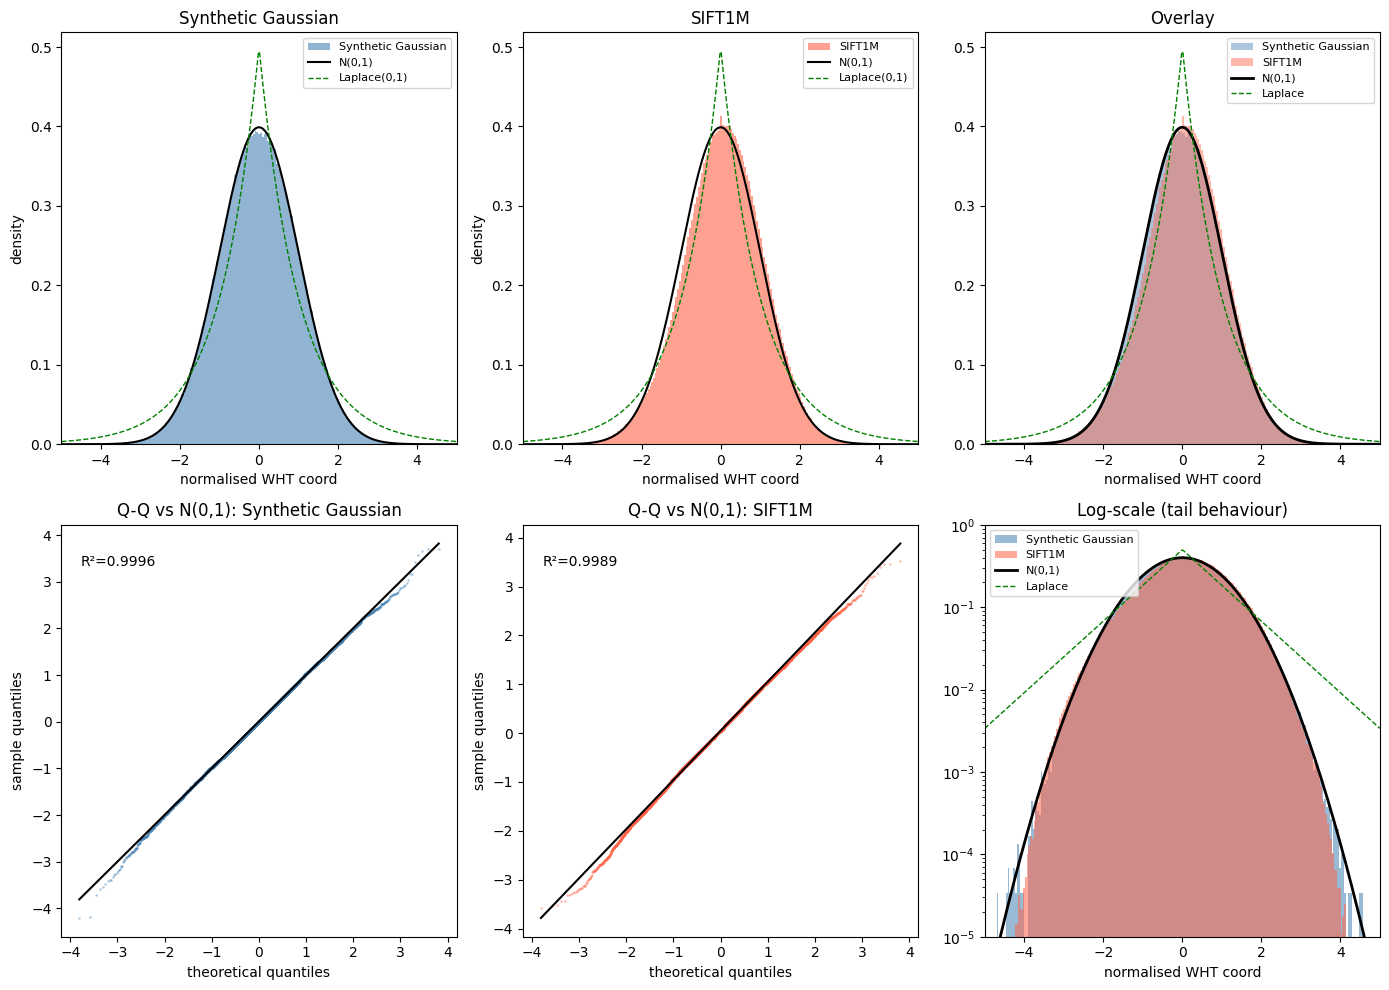

Saved: wht_distribution.png


In [11]:
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)

datasets = [
    (coords_synthetic, "Synthetic Gaussian", "steelblue"),
    (coords_sift,      "SIFT1M",             "tomato"),
]

x_range = np.linspace(-5, 5, 400)
gauss_pdf = stats.norm.pdf(x_range)
laplace_pdf = stats.laplace.pdf(x_range)  # for visual reference

# Row 0: histograms
for col, (coords, label, color) in enumerate(datasets):
    ax = fig.add_subplot(gs[0, col])
    ax.hist(coords, bins=200, density=True, alpha=0.6, color=color, label=label)
    ax.plot(x_range, gauss_pdf,   'k-',  lw=1.5, label='N(0,1)')
    ax.plot(x_range, laplace_pdf, 'g--', lw=1,   label='Laplace(0,1)')
    ax.set_xlim(-5, 5)
    ax.set_title(label)
    ax.set_xlabel("normalised WHT coord")
    ax.set_ylabel("density")
    ax.legend(fontsize=8)

# Overlay comparison
ax_ov = fig.add_subplot(gs[0, 2])
for coords, label, color in datasets:
    ax_ov.hist(coords, bins=200, density=True, alpha=0.45, color=color, label=label)
ax_ov.plot(x_range, gauss_pdf,   'k-',  lw=2, label='N(0,1)')
ax_ov.plot(x_range, laplace_pdf, 'g--', lw=1, label='Laplace')
ax_ov.set_xlim(-5, 5)
ax_ov.set_title("Overlay")
ax_ov.set_xlabel("normalised WHT coord")
ax_ov.legend(fontsize=8)

# Row 1: Q-Q plots vs N(0,1)
for col, (coords, label, color) in enumerate(datasets):
    ax = fig.add_subplot(gs[1, col])
    sample_qq = np.random.default_rng(0).choice(coords, size=min(10_000, len(coords)), replace=False)
    (osm, osr), (slope, intercept, r) = stats.probplot(sample_qq, dist='norm')
    ax.scatter(osm, osr, s=1, alpha=0.3, color=color)
    ax.plot(osm, slope * np.array(osm) + intercept, 'k-', lw=1.5)
    ax.set_title(f"Q-Q vs N(0,1): {label}")
    ax.set_xlabel("theoretical quantiles")
    ax.set_ylabel("sample quantiles")
    ax.annotate(f"R²={r**2:.4f}", xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10)

# Row 1 col 2: log-scale tails comparison
ax_tail = fig.add_subplot(gs[1, 2])
for coords, label, color in datasets:
    ax_tail.hist(coords, bins=200, density=True, alpha=0.55, color=color, label=label)
ax_tail.plot(x_range, gauss_pdf,   'k-',  lw=2, label='N(0,1)')
ax_tail.plot(x_range, laplace_pdf, 'g--', lw=1, label='Laplace')
ax_tail.set_yscale('log')
ax_tail.set_xlim(-5, 5)
ax_tail.set_ylim(1e-5, 1)
ax_tail.set_title("Log-scale (tail behaviour)")
ax_tail.set_xlabel("normalised WHT coord")
ax_tail.legend(fontsize=8)

plt.tight_layout()
plt.savefig("wht_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: wht_distribution.png")

In [12]:
from scipy.special import erfc

def lloyd_max_gaussian(bits: int, max_iter: int = 1000, tol: float = 1e-12) -> tuple:
    """Reproduce computeLloydMax from space_turbo_quant.h."""
    levels = 1 << bits
    half   = levels // 2

    def phi(x):  return np.exp(-0.5 * x * x) / np.sqrt(2 * np.pi)
    def Phi(x):  return 0.5 * erfc(-x / np.sqrt(2))
    def cond_mean(a, b):
        denom = Phi(b) - Phi(a)
        if denom < 1e-15:
            return 0.5 * (a + b)
        return (phi(a) - phi(b)) / denom

    pos_c = np.array([(i + 0.5) * 3.5 / half for i in range(half)])
    for _ in range(max_iter):
        pos_b    = 0.5 * (pos_c[:-1] + pos_c[1:])
        new_c    = np.array([cond_mean(0.0 if i == 0 else pos_b[i-1],
                                       1e10 if i == half - 1 else pos_b[i])
                             for i in range(half)])
        if np.max(np.abs(new_c - pos_c)) < tol:
            break
        pos_c = new_c

    centroids  = np.concatenate([-pos_c[::-1], pos_c]).astype(np.float32)
    boundaries = np.concatenate([
        -0.5 * (pos_c[:-1] + pos_c[1:])[::-1],
        [0.0],
        0.5 * (pos_c[:-1] + pos_c[1:]),
    ]).astype(np.float32)
    return centroids, boundaries


def lloyd_max_empirical(samples: np.ndarray, bits: int, max_iter: int = 200) -> tuple:
    """Train Lloyd-Max on empirical samples (histogram-based)."""
    levels = 1 << bits
    # Init centroids via uniform quantiles of samples
    quantile_points = np.linspace(0, 100, levels + 2)[1:-1]
    centroids = np.percentile(samples, quantile_points).astype(np.float64)

    for _ in range(max_iter):
        # Voronoi: assign each sample to nearest centroid
        boundaries = 0.5 * (centroids[:-1] + centroids[1:])
        indices    = np.searchsorted(boundaries, samples)
        # Update: centroid = mean of assigned samples
        new_centroids = np.array([
            samples[indices == k].mean() if np.any(indices == k) else centroids[k]
            for k in range(levels)
        ])
        if np.max(np.abs(new_centroids - centroids)) < 1e-8:
            break
        centroids = new_centroids

    boundaries = 0.5 * (centroids[:-1] + centroids[1:])
    return centroids.astype(np.float32), boundaries.astype(np.float32)


def quantization_mse(samples: np.ndarray, centroids: np.ndarray, boundaries: np.ndarray) -> float:
    indices  = np.searchsorted(boundaries, samples)
    recon    = centroids[indices]
    return float(np.mean((samples - recon) ** 2))



Functions defined.


In [13]:
results = []

for bits in [3, 4, 5, 6, 7, 8]:   # these are MSE bits (bits_per_coord - 1 in TQ terminology)
    c_gauss, b_gauss   = lloyd_max_gaussian(bits)
    c_empir, b_empir   = lloyd_max_empirical(coords_sift, bits)

    mse_gauss_on_gauss = quantization_mse(coords_synthetic, c_gauss, b_gauss)
    mse_gauss_on_sift  = quantization_mse(coords_sift,      c_gauss, b_gauss)
    mse_empir_on_sift  = quantization_mse(coords_sift,      c_empir, b_empir)

    gain_pct = 100 * (mse_gauss_on_sift - mse_empir_on_sift) / mse_gauss_on_sift
    results.append((bits, mse_gauss_on_gauss, mse_gauss_on_sift, mse_empir_on_sift, gain_pct))
    print(f"MSE bits={bits}: "
          f"Gauss→Gauss={mse_gauss_on_gauss:.5f}  "
          f"Gauss→SIFT={mse_gauss_on_sift:.5f}  "
          f"Empirical→SIFT={mse_empir_on_sift:.5f}  "
          f"gain={gain_pct:+.2f}%")

MSE bits=3: Gauss→Gauss=0.03424  Gauss→SIFT=0.03432  Empirical→SIFT=0.03415  gain=+0.50%
MSE bits=4: Gauss→Gauss=0.00938  Gauss→SIFT=0.00933  Empirical→SIFT=0.00929  gain=+0.40%
MSE bits=5: Gauss→Gauss=0.00248  Gauss→SIFT=0.00244  Empirical→SIFT=0.00246  gain=-0.90%
MSE bits=6: Gauss→Gauss=0.00064  Gauss→SIFT=0.00064  Empirical→SIFT=0.00082  gain=-28.93%
MSE bits=7: Gauss→Gauss=0.00019  Gauss→SIFT=0.00019  Empirical→SIFT=0.00031  gain=-65.61%
MSE bits=8: Gauss→Gauss=0.00006  Gauss→SIFT=0.00006  Empirical→SIFT=0.00012  gain=-114.98%


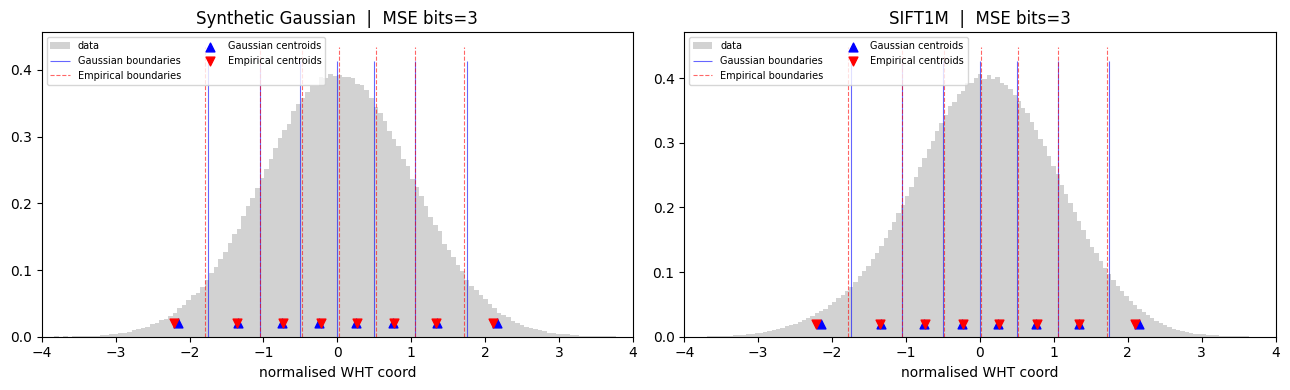

Saved: codebook_comparison_bits3.png


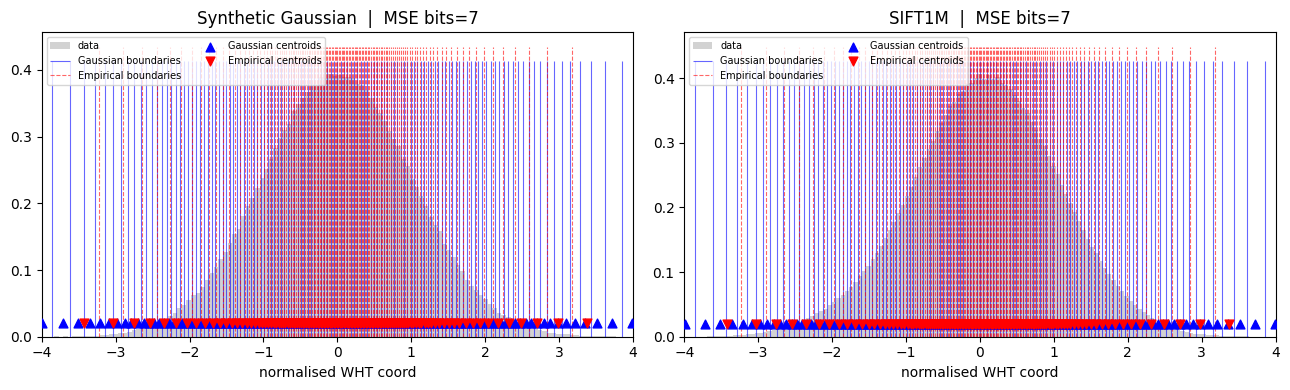

Saved: codebook_comparison_bits7.png


In [14]:
for target_bits in [3, 7]:  # TQ 4-bit and 8-bit modes
    c_g, b_g = lloyd_max_gaussian(target_bits)
    c_e, b_e = lloyd_max_empirical(coords_sift, target_bits)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    x_ref = np.linspace(-4, 4, 400)

    for ax, (coords, label) in zip(axes, [
        (coords_synthetic, "Synthetic Gaussian"),
        (coords_sift,      "SIFT1M"),
    ]):
        ax.hist(coords, bins=150, density=True, alpha=0.35, color='gray', label='data')
        ax.vlines(b_g, 0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 0.6,
                  colors='blue', lw=0.8, alpha=0.6, label='Gaussian boundaries')
        ax.vlines(b_e, 0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 0.6,
                  colors='red',  lw=0.8, alpha=0.6, linestyle='--', label='Empirical boundaries')
        ax.scatter(c_g, np.zeros_like(c_g) + 0.02, marker='^', color='blue', s=40, zorder=5, label='Gaussian centroids')
        ax.scatter(c_e, np.zeros_like(c_e) + 0.02, marker='v', color='red',  s=40, zorder=5, label='Empirical centroids')
        ax.set_xlim(-4, 4)
        ax.set_title(f"{label}  |  MSE bits={target_bits}")
        ax.set_xlabel("normalised WHT coord")
        ax.legend(fontsize=7, ncol=2)

    plt.tight_layout()
    plt.savefig(f"codebook_comparison_bits{target_bits}.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: codebook_comparison_bits{target_bits}.png")

In [15]:
HF_CACHE = Path.home() / ".cache" / "turboquant" / "hf"
extra_datasets = {}

for key in ["openai-v3-small", "openai-v3-large", "beir-msmarco"]:
    path = HF_CACHE / key / "embeddings_100000.npy"
    if not path.exists():
        path = next((HF_CACHE / key).glob("embeddings_*.npy"), None) if (HF_CACHE / key).exists() else None
    if path and path.exists():
        vecs = np.load(path)
        print(f"Loaded {key}: {vecs.shape}")
        extra_datasets[key] = vecs
    else:
        print(f"  {key}: not cached — skipping")

for key, vecs in extra_datasets.items():
    coords = wht_coordinates(vecs, rot_seed=42, n_sample=20_000)
    distribution_stats(coords, key)

  openai-v3-small: not cached — skipping
  openai-v3-large: not cached — skipping
  beir-msmarco: not cached — skipping
